# NW Ontario lamprophyre dykes ca. 1144 Ma paleomagnetic pole

## Geologic context

The lamprophyre (and related alkaline) dykes of northwestern Ontario intrude the
southern Superior Province coeval with the Abitibi dyke swarm (Piispa et
al., 2018). 40Ar/39Ar phlogopite and U-Pb perovskite dates of
1144 ± 7 Ma (Queen et al., 1996) provide age constraints on the dykes. The dykes carry a steep,
mixed-polarity magnetization constrained to be primary by a positive baked-contact
test.

## Pole

This notebook recreates the lamprophyre dyke pole at the dyke level from the 19
dykes of Piispa et al. (2018), excluding the Abitibi dykes (treated separately in
`1141_Abitibi`) and the baked/unbaked contact-test sites.

## Age Constraints
- Current age bracket: nominal age 1144 Ma, lomagage 1137 Ma, himagage 1151 Ma. 
- 1144±7. Ma Ar-Ar phlogopite and 1144 +6/-4 U-Pb perovskite. 40Ar/39Ar phlogopite and U-Pb perovskite dating by Queen et al., 1996. Piispa et al., 2018 also compile previous baddeleyite dates from unpublished dates from Heaman, and correlated with Krogh 1987 baddeleyite age from the Abitibi dikes with the interpretation that the lamprophyre dikes and abitibi dikes are of the similar pulse of MCR initiation magmatism. 
- 
## References

- Paleomagnetic source: Piispa, E. J., Smirnov, A. V., Pesonen, L. J., & Mitchell, R. H. (2018). Paleomagnetism and geochemistry of ∼1144-Ma lamprophyre dikes, northwestern Ontario: Implications for the North American polar wander and plate velocities. Journal of Geophysical Research: Solid Earth. https://doi.org/10.1029/2018jb015992
- Geochronology / age-constraint note (compilation): Queen, M., Hanes, J. A., Archibald, D. A., Farrar, E., & Heaman, L. M. (1996). 40Ar/39Ar phlogopite and U – Pb perovskite dating of lamprophyre dykes from the eastern Lake Superior region: Evidence for a 1.14 Ga magmatic precursor to Midcontinent Rift volcanism. Canadian Journal of Earth Sciences, 33(6), 958–965. https://doi.org/10.1139/e96-072

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data and the 19-dyke pole

Loaded from `../data/1144_Lamprophyre/`. The pole uses the 19 lamprophyre dykes;
most are reversed-polarity (steep down-to-southeast), several normal — a reversal
test.

In [2]:
sites = pd.read_csv('../data/1144_Lamprophyre/sites.txt', sep='\t', skiprows=1)
abitibi = ['A4a', 'A7abi', 'A3-abi', 'A5-abi', 'A6-1-a', 'A6-2-a', 'A8-abi', 'SL13']
baked = ['MM2 Baked', 'MM2 Unbaked', 'D1 Baked', 'D1 Unbaked']
lamp = sites[(~sites['site'].isin(abitibi + baked)) & (sites['vgp_lat'].notna())].reset_index(drop=True)
study_lat, study_lon = 48.4, 273.6
print(f'{len(lamp)} lamprophyre dykes; reversed:', lamp[lamp['dir_inc'] < 0]['site'].tolist())
lamp[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

19 lamprophyre dykes; reversed: ['ML2', 'D15', 'D16 H', 'MM3', 'D14', 'MM1', 'D10 H', 'D11', 'D12', 'MM2', 'D1', 'D3 H', 'D4', 'D7 H']


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,ML2,103.8,-61.4,125.0,5.5,6,38.6,206.9
1,D15,126.2,-59.4,46.2,10.2,5,51.5,191.2
2,D16 H,118.8,-57.2,47.2,7.6,8,45.4,192.9
3,MM3,112.3,-85.9,65.0,9.9,4,51.3,261.2
4,D14,124.7,-67.4,48.0,9.8,6,54.9,207.1
5,MM1,106.3,-69.8,61.6,12.9,3,45.7,218.8
6,D10 H,184.6,-71.4,45.9,11.4,7,82.2,292.6
7,D11,147.7,-55.6,25.5,11.7,6,63.3,167.1
8,D12,123.1,-64.9,19.6,14.0,6,52.7,202.5
9,MM2,110.8,-59.7,58.4,13.3,2,41.8,200.9


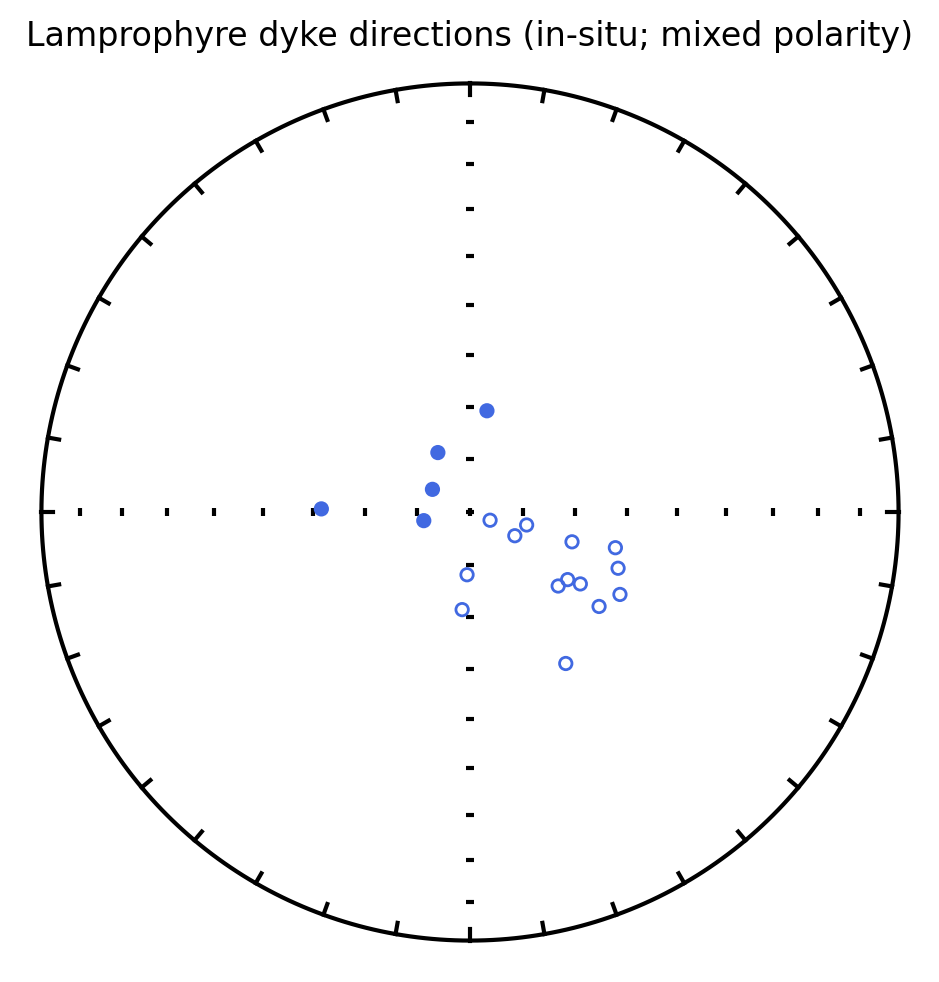

Plon: 223.3  Plat: 57.9
Number of directions in mean (n): 19
Angular radius of 95% confidence (A_95): 9.2
Precision parameter (k) estimate: 14.2

Piispa et al. (2018) Pole Lc: 58.0 N / 223.3 E, A95 9.2, N=19


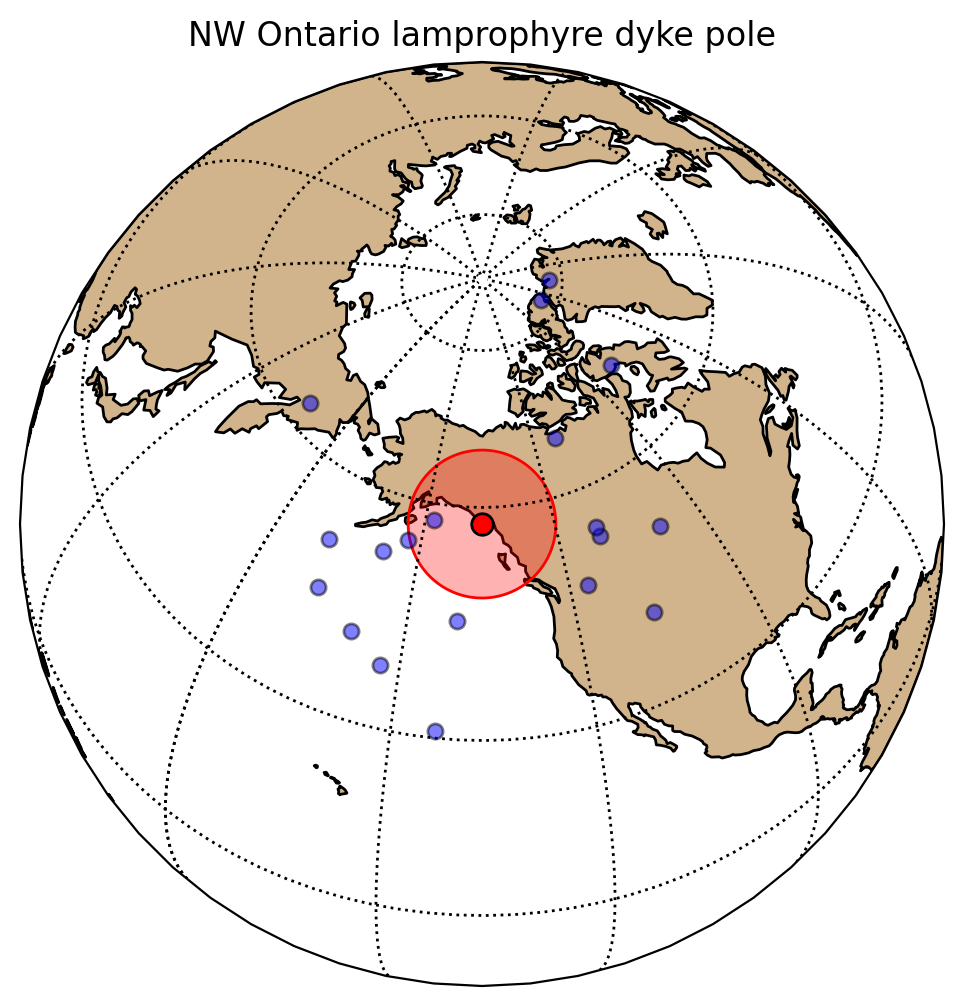

In [3]:
ipmag.plot_net()
ipmag.plot_di(lamp['dir_dec'].tolist(), lamp['dir_inc'].tolist(), color='royalblue', marker='o')
plt.title('Lamprophyre dyke directions (in-situ; mixed polarity)')
plt.show()

vgp_block, pole_mean = pt.compute_mean_pole(lamp, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nPiispa et al. (2018) Pole Lc: 58.0 N / 223.3 E, A95 9.2, N=19')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('NW Ontario lamprophyre dyke pole')
plt.show()

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(lamp, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)

Dec: 306.4  Inc: 72.1
Number of directions in mean (n): 19
Angular radius of 95% confidence (a_95): 5.5
Precision parameter (k) estimate: 37.8


## Reversal test (McFadden & McElhinny, 1990)

The 19 lamprophyre dykes are of mixed polarity (14 reversed, 5 normal). The
McFadden & McElhinny (1990) reversal test inverts the reversed group to normal
polarity and applies a Watson V common-mean test, returning a classification
(A/B/C) or a negative result.

normal-polarity dykes  : ['D2 H', 'D5', 'D9', 'D13', 'ML1']
reversed-polarity dykes: ['ML2', 'D15', 'D16 H', 'MM3', 'D14', 'MM1', 'D10 H', 'D11', 'D12', 'MM2', 'D1', 'D3 H', 'D4', 'D7 H']
Results of Watson V test: 

Watson's V:           2.6
Critical value of V:  7.2
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 8.4
Critical angle for M&M1990:   13.8
The McFadden and McElhinny (1990) classification for
this test is: 'C'


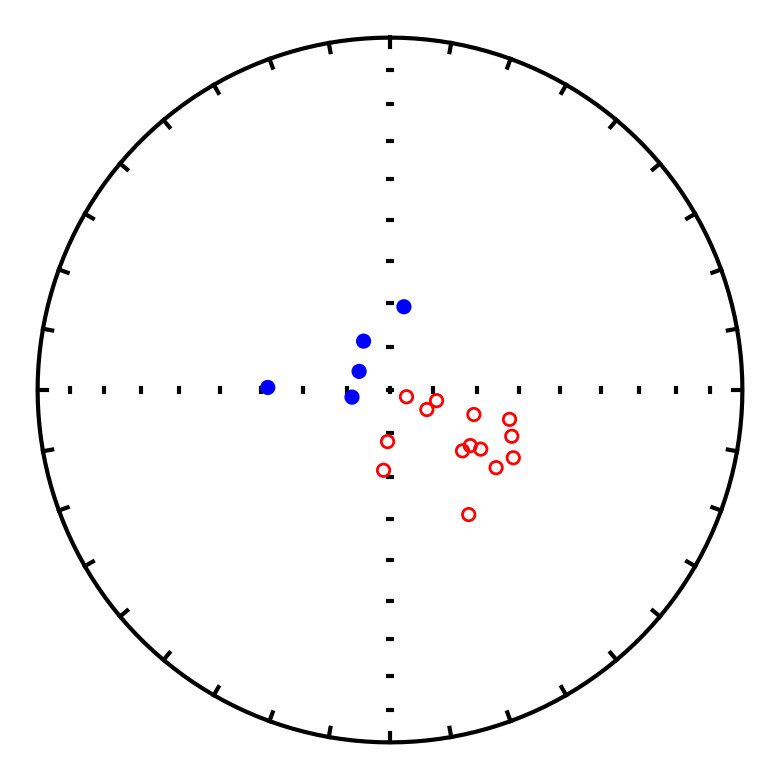

In [5]:
print('normal-polarity dykes  :', lamp[lamp['dir_inc'] > 0]['site'].tolist())
print('reversed-polarity dykes:', lamp[lamp['dir_inc'] < 0]['site'].tolist())

# McFadden & McElhinny (1990) reversal test: Watson V common-mean test + classification
ipmag.reversal_test_MM1990(dec=lamp['dir_dec'].tolist(), inc=lamp['dir_inc'].tolist(),
                           plot_stereo=True)
plt.show()

## Field test: baked contact

Dykes D1 and MM2 expose baked host-rock margins that carry the dyke direction,
while the unbaked host away from the contact differs — a positive baked-contact
test.

In [6]:
bc = sites[sites['site'].isin(['D1 Baked', 'D1 Unbaked', 'MM2 Baked', 'MM2 Unbaked'])]
print(bc[['site', 'dir_dec', 'dir_inc', 'dir_alpha95']].to_string(index=False))

       site  dir_dec  dir_inc  dir_alpha95
  MM2 Baked    170.7    -82.4          NaN
MM2 Unbaked     74.7     86.0          NaN
   D1 Baked     60.9    -75.6          7.9
 D1 Unbaked     25.0     33.0          3.2


## Paleosecular variation

A_95 of 9.2 passes Deenen et al. (2011) criteria of being between 3.7 and 12.8 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

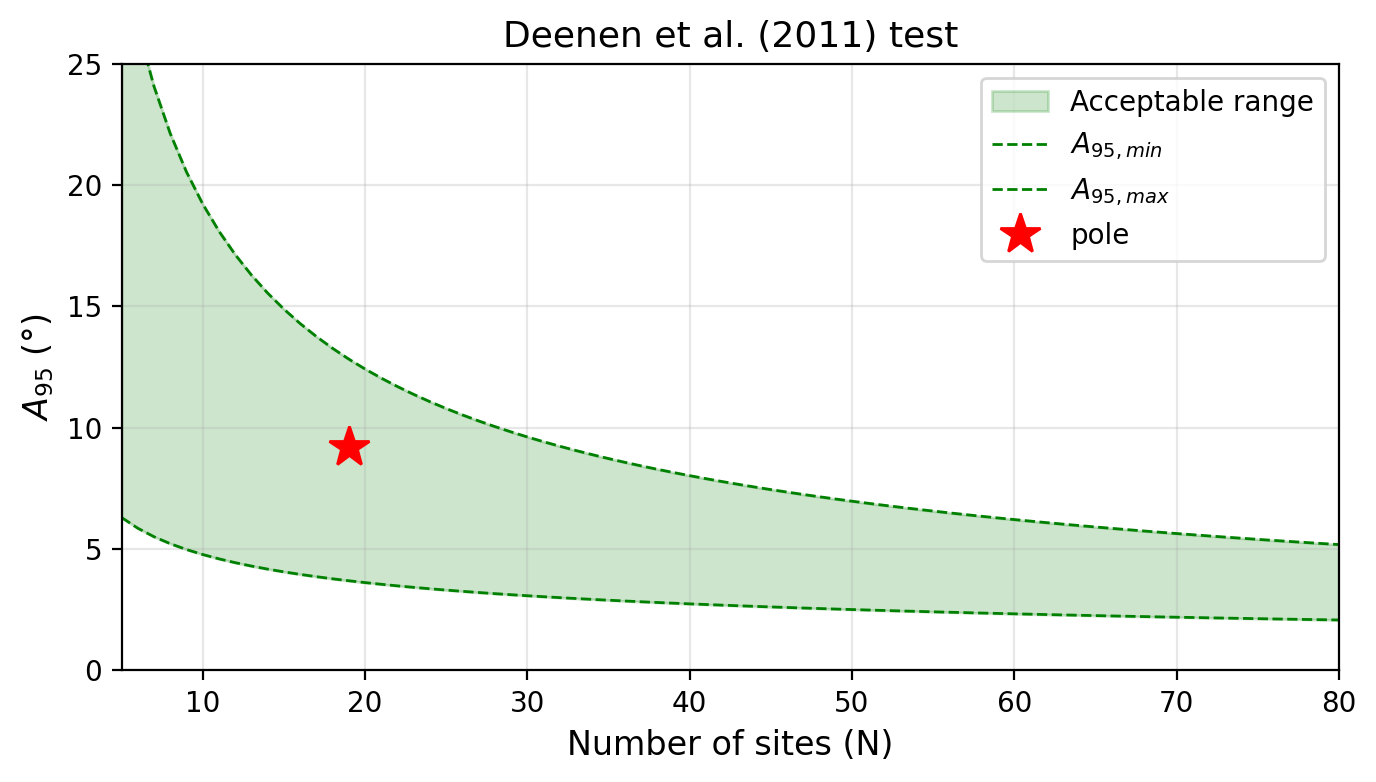

In [7]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(223.11577062764465),
 'Inc': np.float64(57.605489864852956),
 'N': 19,
 'Mu': np.float64(1.0636308353904993),
 'Mu_critical': 1.207,
 'Me': np.float64(1.0014684045578368),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

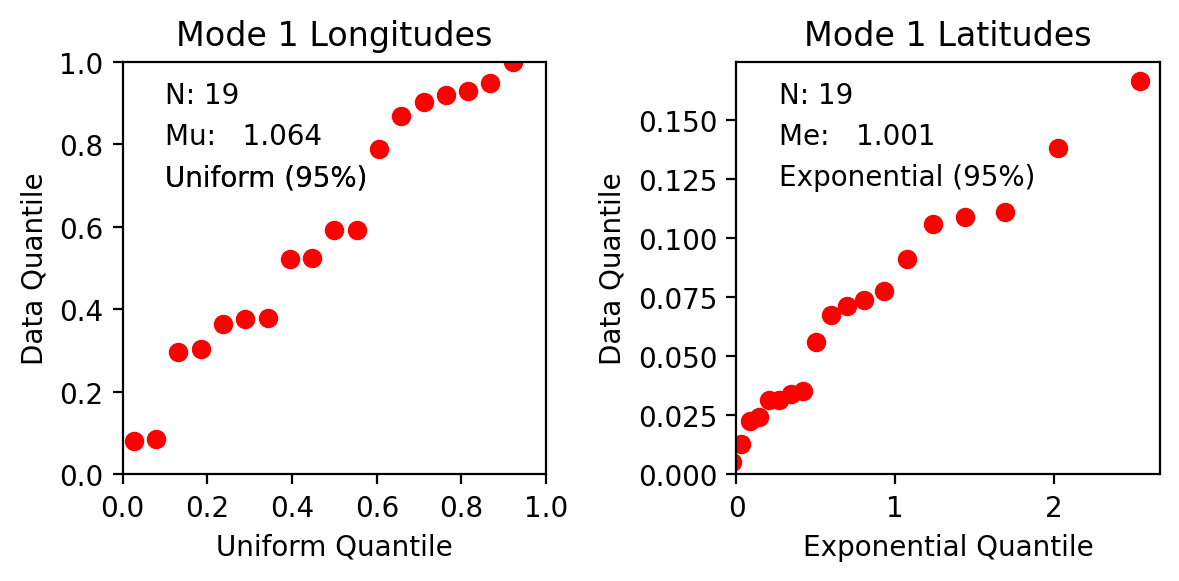

In [8]:
fishqq_result = pt.fishqq_vgps(lamp, unify_polarity=True)
fishqq_result

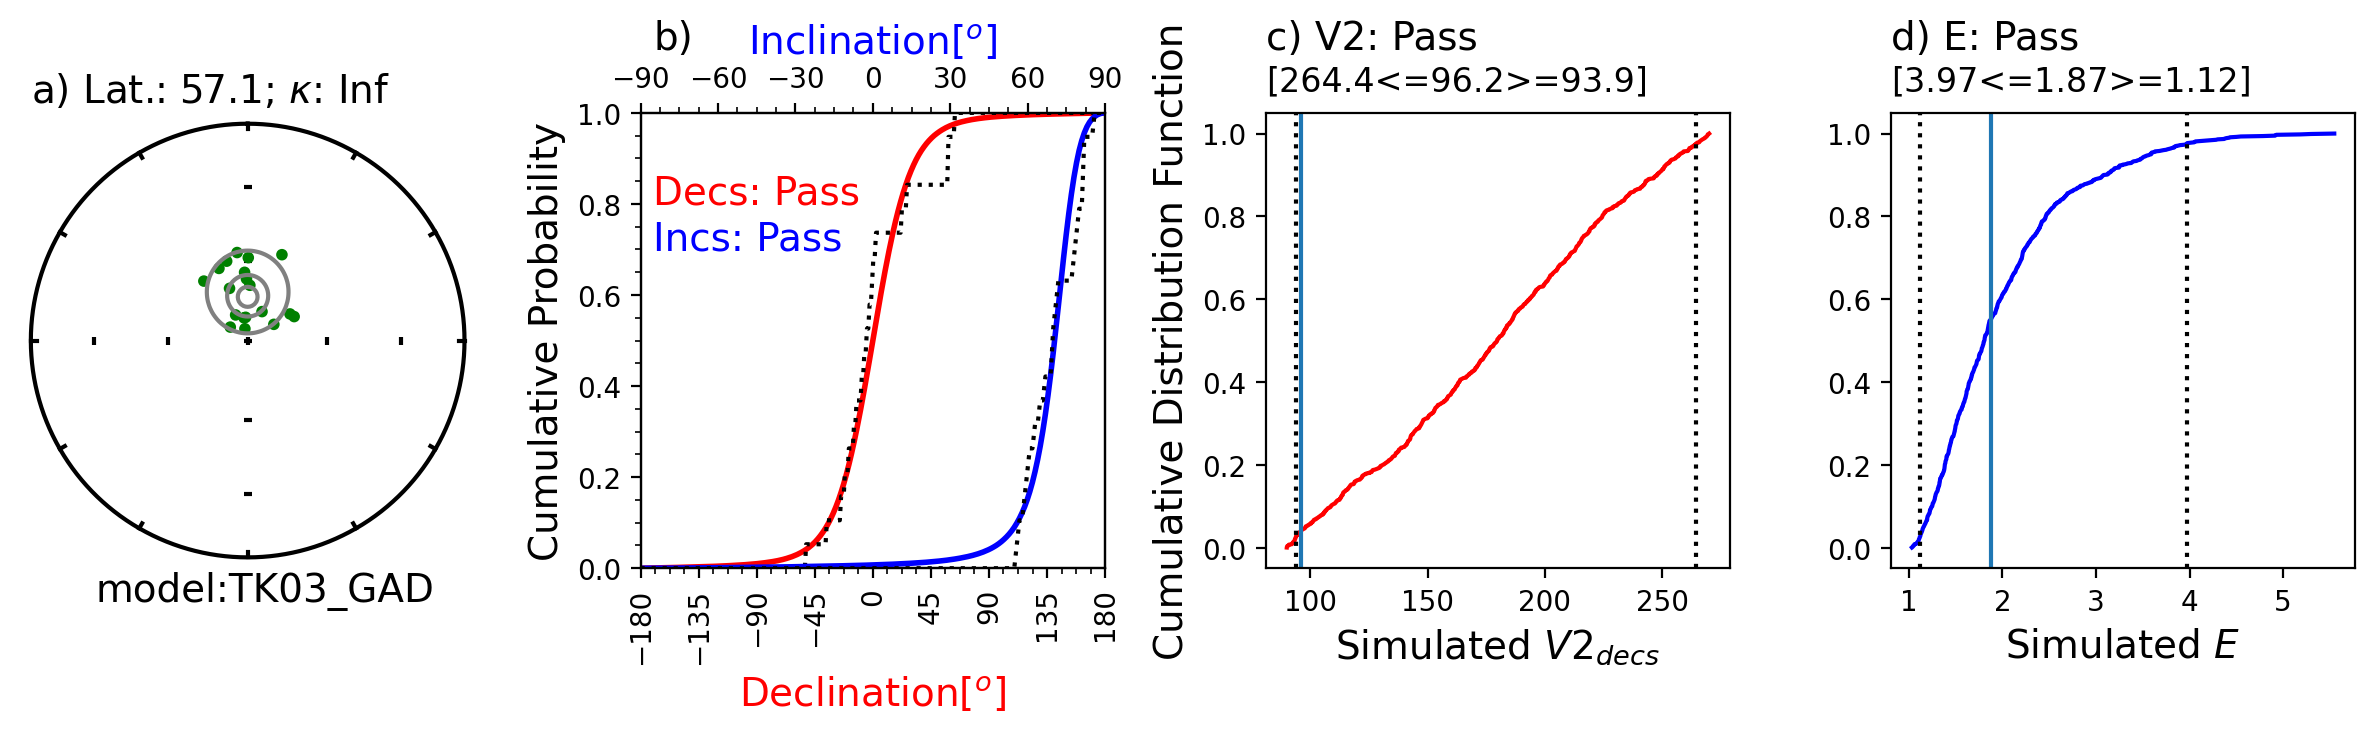

paleolatitude = 57.1 deg; elongation E = 1.87 (consistent with TK03.GAD)


In [9]:
_slat, _slon = float(lamp['lat'].mean()), float(lamp['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(lamp, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(lamp, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The lamprophyre pole in the context of the Laurentia APWP

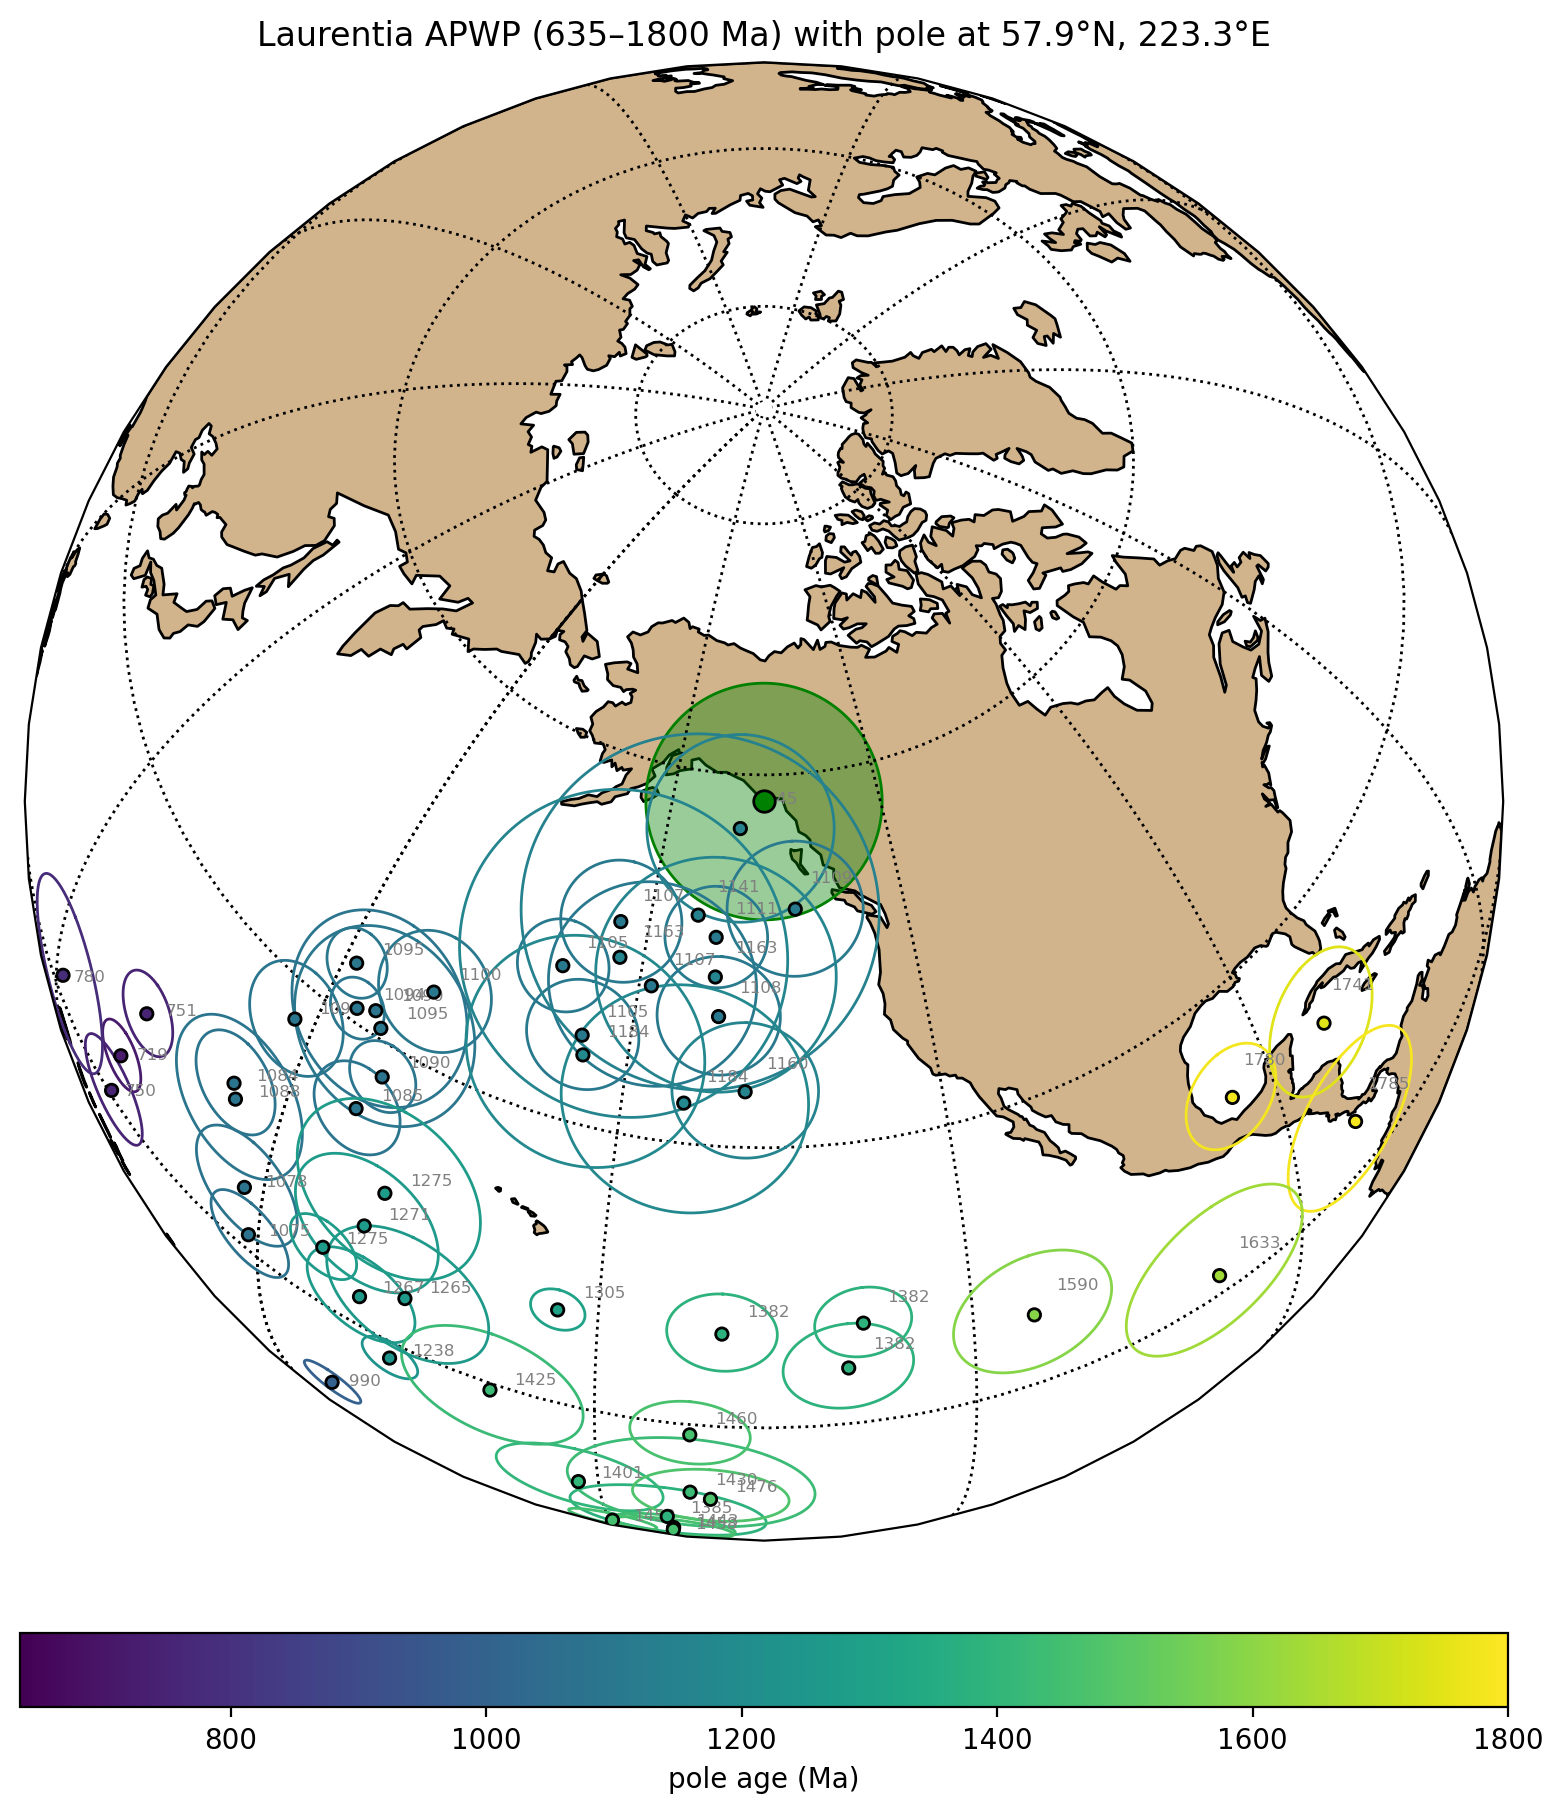

In [10]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

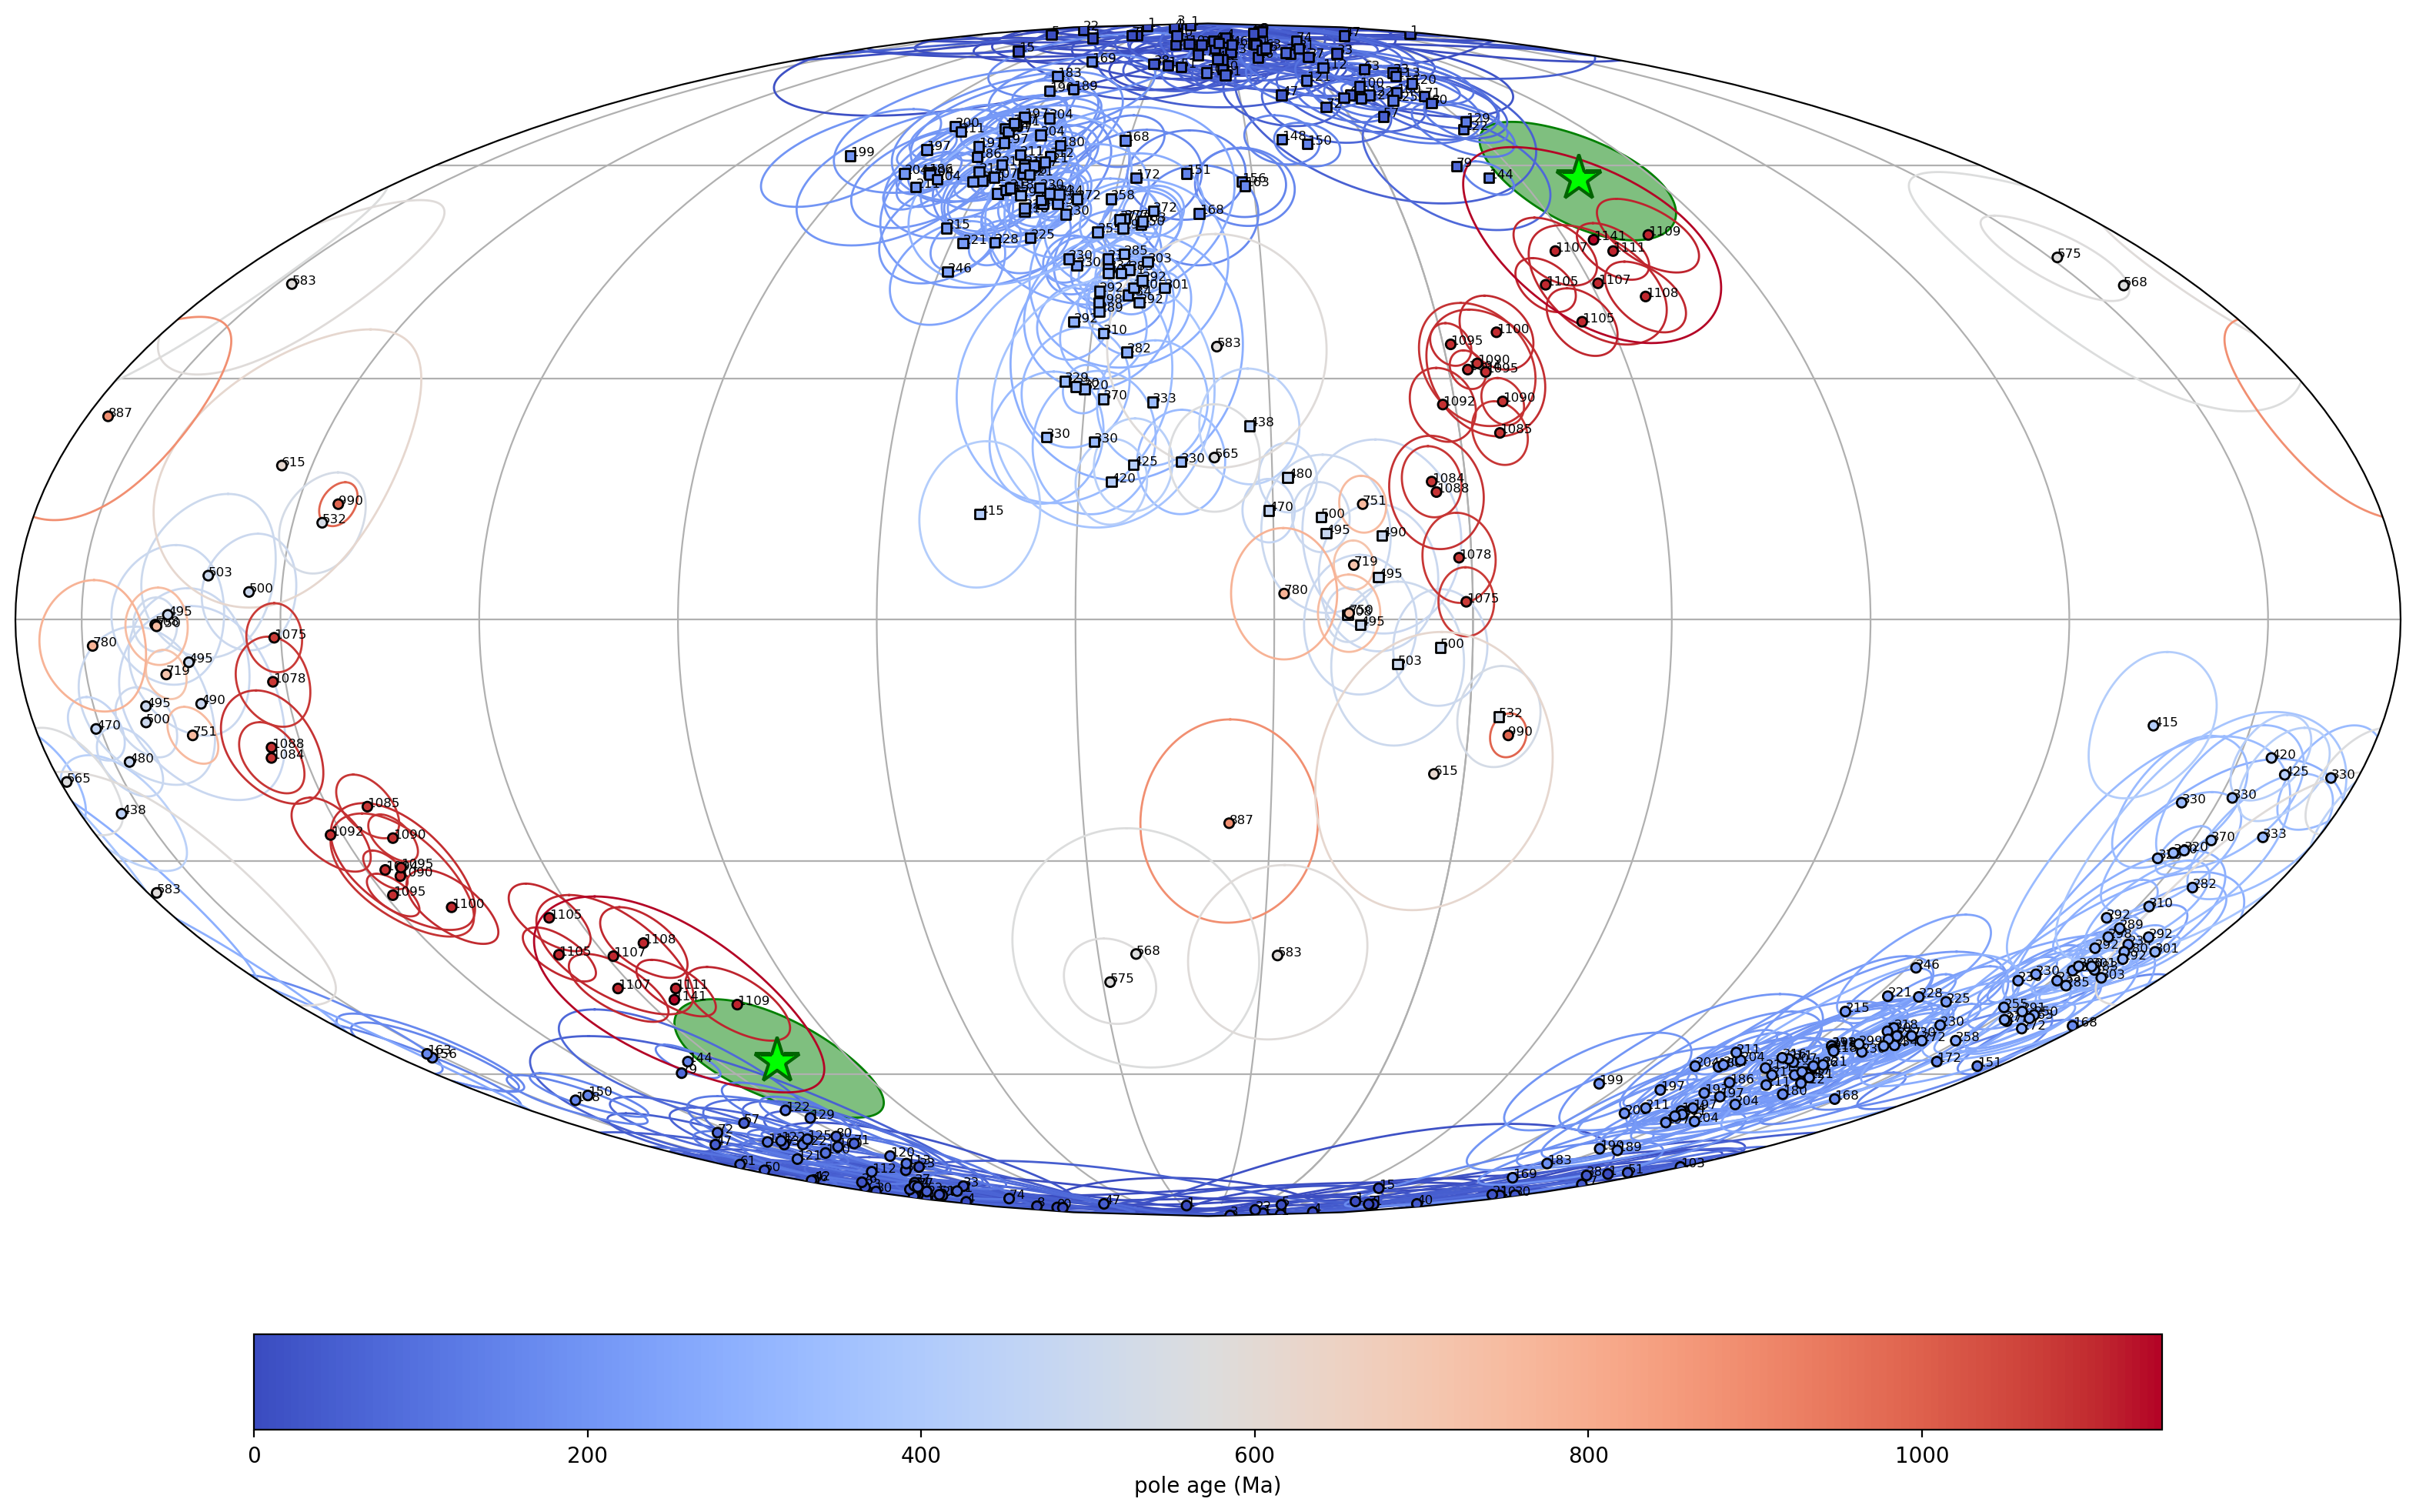

<GeoAxes: >

In [11]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('NW Ontario Lamprophyre Dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1144)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | 40Ar/39Ar phlogopite and U-Pb perovskite 1144 ± 7 Ma (Queen et al., 1996). |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization, PCA; N = 19 dykes, A95 = 9.2° passes the Deenen et al. (2011) envelope. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence characterized by rock-magnetic experiments (Piispa et al., 2018). |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test (dykes D1, MM2: baked margins carry the dyke direction, unbaked host differs). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous southern Superior Province; vertical dykes need no tilt correction. |
| 6 | Presence of reversals | **1** | Mixed polarity (14 reversed, 5 normal); positive McFadden & McElhinny (1990) reversal test (class C). |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **7/7** | Grade A |

## Nordic workshop summary

The lamprophyre dyke pole is recreated from the 19 dykes of Piispa et al. (2018),
reproducing the published Pole Lc (58.0°N/223.3°E, A95 9.2°). The prior
compilation combined these dykes with the Abitibi swarm (GPMDB 9887); they are
reported separately here. Positive baked-contact test (R4 = C), mixed polarity
with a positive reversal test (R6 = 1), and the 1144 Ma age give a Grade A,
R = 7 pole.

## Pole comparison

### NW Ontario lamprophyre dyke pole

| | This study (site VGPs) | Piispa et al. (2018) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary ChRM (magnetite); mixed polarity | Combined mean (R + N), Lamprophyres | — |
| N (sites) | 19 | 19 | — |
| N (specimens) | 120 | 121 | — |
| Dec (°) | 306.4 | 306.4 | — |
| Inc (°) | 72.1 | 72.1 | — |
| k (direction) | 37.8 | 37.8 | — |
| α95 (direction, °) | 5.5 | 5.5 | — |
| Pole lat (°N) | 57.9 | 58.0 | — |
| Pole lon (°E) | 223.3 | 223.3 | — |
| A95 (°) | 9.2 | 9.2 | — |
| k (pole) | 14.2 | 14.2 | — |
| dp / dm (°) | — | — | — |

Piispa et al. (2018) values are the "Combined mean (R + N), Lamprophyres" row of Table 3 (p. 9; reported as `19(121)  306.4  72.1  5.5  37.8  58.0  223.3  A95 = 9.2, K = 14.2`). This result was not included in the Evans et al. (2021) compilation.


In [12]:
lamp_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='NW Ontario Lamprophyre Dykes',
    sites=lamp,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite); mixed polarity',
    tests='C+ (positive baked-contact test, dykes D1 and MM2) and R+ (positive reversal test, class C; 14 reversed, 5 normal)',
    gpmdb_number='9886',
    magic_id='20635',
    percent_reversed=74,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='C', R5=1, R6=1, R7=1, Grade='A',
    nominal_age=1144, lomagage=1137, himagage=1151,
    REF_method="- Current age bracket: nominal age 1144 Ma, lomagage 1137 Ma, himagage 1151 Ma. \n- 1144±7. Ma Ar-Ar phlogopite and 1144 +6/-4 U-Pb perovskite. 40Ar/39Ar phlogopite and U-Pb perovskite dating by Queen et al., 1996. Piispa et al., 2018 also compile previous baddeleyite dates from unpublished dates from Heaman, and correlated with Krogh 1987 baddeleyite age from the Abitibi dikes with the interpretation that the lamprophyre dikes and abitibi dikes are of the similar pulse of MCR initiation magmatism. \n-",
    POLE_AUTHORS='Piispa, E. L., Smirnov, A. V., Pesonen, L. J., & Mitchell, R. H.',
    YEAR=2018,
    JOURNAL='Journal of Geophysical Research: Solid Earth',
    VOLUME='123',
    VPAGES='',
    TITLE='Paleomagnetism and Geochemistry of ~1144-Ma Lamprophyre Dikes, Northwestern Ontario: Implications for the Midcontinent Rift',
    COMMENT='Mean of site level VGPs as in Piispa et al. (2018).'
)
pt.save_nordic_summary(lamp_summary, '1144_Lamprophyre')
lamp_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,NW Ontario Lamprophyre Dykes,GPMDB:9886 MagIC:20635,Characteristic remanent magnetization (magneti...,"C+ (positive baked-contact test, dykes D1 and ...",0,48.4,273.6,19,120,...,1151,"- Current age bracket: nominal age 1144 Ma, lo...",NW Ontario Lamprophyre Dykes,"Piispa, E. L., Smirnov, A. V., Pesonen, L. J.,...",2018,Journal of Geophysical Research: Solid Earth,123,,Paleomagnetism and Geochemistry of ~1144-Ma La...,Mean of site level VGPs as in Piispa et al. (2...
